# Import and eval functions

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, h5py, gc, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
import concurrent.futures as cf
from pathlib import Path
from torch.utils.data import DataLoader

REPO_ROOT = "./"
proj = Path(REPO_ROOT).resolve()

# allow: import ADCNN.*
sys.path.insert(0, str(proj))

# allow: import utils.*  (where utils == ADCNN/utils)
sys.path.insert(0, str(proj / "ADCNN"))

import ADCNN.inference.postprocess as postprocess
from ADCNN.data.datasets import H5TiledDataset
from ADCNN.inference.predict import load_model, predict_tiles_to_full
import ADCNN.evaluation.detection as evals
import ADCNN.evaluation.threshold_scan as threshold_scan

MODEL_CKPT = "./checkpoints/ckpt_last.pt"

In [2]:
def calculate_model_metrics (catalog, predictions, ground_truth, thr_points=100, stack_fp=None, best_threshold=None):
    catalog = catalog.copy()
    if best_threshold is None:
        threshold_df = threshold_scan.scan_thresholds(catalog=catalog, predictions=predictions, ground_truth=ground_truth, stack_fp=stack_fp, n_points=thr_points)
        threshold_scan.plot_fscore(threshold_df["thr"], pix_f1=threshold_df.get("pix_f1"), pix_f2=threshold_df.get("pix_f2"),
                               obj_f1=threshold_df.get("obj_f1"), obj_f2=threshold_df.get("obj_f2"), title="Pixelwise vs Objectwise F-scores")
        threshold_scan.plot_roc(threshold_scan.compute_roc(threshold_df["pix_tp"], threshold_df["pix_fp"], threshold_df["pix_tn"], threshold_df["pix_fn"]))
        threshold_scan.plot_froc(threshold_scan.compute_froc(thr=threshold_df["thr"], obj_tp=threshold_df["obj_tp"], obj_fp=threshold_df["obj_fp"], obj_fn=threshold_df["obj_fn"], n_images=50),
                             title="FROC (objectwise)")
        best_threshold = threshold_df["thr"][threshold_df["obj_f2"].argmax()]
    _,_,catalog = evals.full_confusion(catalog=catalog, ground_truth= ground_truth,predictions=predictions, stack_fp=stack_fp, threshold=best_threshold, verbose=True)
    _ = evals.combined_confusion_separate(catalog=test_catalog, ground_truth=gt_test, predictions=p, threshold=best_threshold, verbose=True, stack_mask=stack_fp)
    _ = evals.plot_detect_hist(catalog, "PSF_mag", bins=12, title="NN detections vs PSF_mag threshold=" + str(round(best_threshold, 3)))
    _ = evals.plot_detect_hist(catalog, "trail_length", bins=12, title="Detections vs trail length threshold="+ str(round(best_threshold, 3)))
    _ = evals.plot_detect_hist(catalog, "SNR", bins=10, title="Detections vs SNR threshold="+ str(round(best_threshold, 3)), xlim=[0, 10], density=True)
    _ = evals.plot_completeness_2d(catalog, snr_bins=10, trail_bins=10, title="Model completeness")
    _ = evals.plot_completeness_2d(catalog, snr_bins=10, trail_bins=10, detected=(~catalog["stack_detection"].values.astype(bool) & catalog["nn_detected"].values.astype(bool)),
                                   title="Model detection but not stack detection")
    plt.show()
    return catalog

def get_stack_metrics (catalog, fp_mask):
    tp = (catalog["stack_detection"]==True).sum()
    fn = (catalog["stack_detection"]==False).sum()
    fp = fp_mask.max(axis=(1, 2)).sum()
    return  {"TP": tp, "FP": fp, "FN": fn, "TN": pd.NA}

In [3]:
import os
import math
import numpy as np
from scipy import ndimage as ndi
from concurrent.futures import ProcessPoolExecutor


# =============================================================================
# Single-image second-stage detector
# =============================================================================

def second_stage_detect_fast(
    prob: np.ndarray,
    *,
    t_low: float = 0.10,
    score_thr: float = 0.99,
    score_mode: str = "max",          # "max" or "topk_mean"
    top_k: int = 5,
    min_area: int = 2,
    min_span: int = 3,
    min_aspect: float = 2.0,
    connectivity: int = 8,
    return_mask: bool = False,
):
    """
    Fast second-stage detector for one 2D probability map.
    """
    prob = np.asarray(prob)
    if prob.ndim != 2:
        raise ValueError("prob must be a 2D array")

    if connectivity == 8:
        structure = np.ones((3, 3), dtype=np.uint8)
    elif connectivity == 4:
        structure = np.array([[0, 1, 0],
                              [1, 1, 1],
                              [0, 1, 0]], dtype=np.uint8)
    else:
        raise ValueError("connectivity must be 4 or 8")

    binary = prob >= t_low
    labels, nlab = ndi.label(binary, structure=structure)

    if nlab == 0:
        if return_mask:
            return [], np.zeros_like(binary, dtype=bool)
        return []

    lab_ids = np.arange(1, nlab + 1)

    areas = ndi.sum(binary, labels=labels, index=lab_ids).astype(np.int32)
    max_scores = ndi.maximum(prob, labels=labels, index=lab_ids)
    boxes = ndi.find_objects(labels)

    kept = []
    keep_labels = []

    for lab in lab_ids:
        idx = lab - 1
        area = int(areas[idx])
        if area < min_area:
            continue

        slc = boxes[idx]
        if slc is None:
            continue

        y0, y1 = slc[0].start, slc[0].stop
        x0, x1 = slc[1].start, slc[1].stop
        h = y1 - y0
        w = x1 - x0

        long_dim = max(h, w)
        short_dim = min(h, w)

        if long_dim < min_span:
            continue

        aspect = long_dim / max(short_dim, 1)
        if aspect < min_aspect:
            continue

        if score_mode == "max":
            score = float(max_scores[idx])

        elif score_mode == "topk_mean":
            comp = labels[slc] == lab
            vals = prob[slc][comp]
            k = min(top_k, vals.size)

            if k == vals.size:
                score = float(vals.mean())
            else:
                top = np.argpartition(vals, -k)[-k:]
                score = float(vals[top].mean())
        else:
            raise ValueError("score_mode must be 'max' or 'topk_mean'")

        if score < score_thr:
            continue

        local_prob = prob[slc]
        local_mask = (labels[slc] == lab)
        masked = np.where(local_mask, local_prob, -1.0)
        py, px = np.unravel_index(np.argmax(masked), masked.shape)
        py += y0
        px += x0

        kept.append({
            "label": int(lab),
            "score": score,
            "area": area,
            "bbox": (y0, y1, x0, x1),
            "height": h,
            "width": w,
            "aspect": float(aspect),
            "peak_yx": (int(py), int(px)),
        })
        keep_labels.append(int(lab))

    if not return_mask:
        return kept

    if keep_labels:
        keep_mask = np.isin(labels, np.asarray(keep_labels, dtype=labels.dtype))
    else:
        keep_mask = np.zeros_like(binary, dtype=bool)

    return kept, keep_mask


# =============================================================================
# Multiprocessing helpers
# =============================================================================

def _detect_chunk(args):
    """
    Worker for a chunk of images.
    Returns (start_idx, detections, masks_or_None)
    """
    start_idx, prob_chunk, kwargs = args

    n = prob_chunk.shape[0]
    detections = []
    masks = [] if kwargs["return_mask"] else None

    for j in range(n):
        res = second_stage_detect_fast(prob_chunk[j], **kwargs)
        if kwargs["return_mask"]:
            det, mask = res
            detections.append(det)
            masks.append(mask)
        else:
            detections.append(res)

    if kwargs["return_mask"]:
        masks = np.stack(masks, axis=0) if n > 0 else np.empty_like(prob_chunk, dtype=bool)

    return start_idx, detections, masks


# =============================================================================
# Main batch detector
# =============================================================================

def second_stage_detect_batch_mp(
    probs: np.ndarray,
    *,
    t_low: float = 0.10,
    score_thr: float = 0.99,
    score_mode: str = "max",
    top_k: int = 5,
    min_area: int = 2,
    min_span: int = 3,
    min_aspect: float = 2.0,
    connectivity: int = 8,
    return_mask: bool = False,
    max_workers: int | None = None,
    chunk_size: int = 32,
):
    """
    Multiprocessed second-stage detection for a batch of probability maps.

    Parameters
    ----------
    probs : np.ndarray
        Array of shape (N, H, W).
    t_low, score_thr, score_mode, top_k, min_area, min_span, min_aspect,
    connectivity, return_mask : see second_stage_detect_fast
    max_workers : int or None
        Number of processes. If None, uses os.cpu_count().
    chunk_size : int
        Number of images per submitted process task.
        Larger chunks reduce multiprocessing overhead.

    Returns
    -------
    detections : list[list[dict]]
        detections[i] is the kept-candidate list for probs[i].
    masks : np.ndarray, optional
        Boolean array of shape (N, H, W), only if return_mask=True.
    """
    probs = np.asarray(probs)
    if probs.ndim != 3:
        raise ValueError("probs must have shape (N, H, W)")

    n_images = probs.shape[0]
    if n_images == 0:
        if return_mask:
            return [], np.zeros_like(probs, dtype=bool)
        return []

    if max_workers is None:
        max_workers = os.cpu_count() or 1
    max_workers = max(1, int(max_workers))

    chunk_size = max(1, int(chunk_size))

    kwargs = {
        "t_low": t_low,
        "score_thr": score_thr,
        "score_mode": score_mode,
        "top_k": top_k,
        "min_area": min_area,
        "min_span": min_span,
        "min_aspect": min_aspect,
        "connectivity": connectivity,
        "return_mask": return_mask,
    }

    tasks = []
    for start in range(0, n_images, chunk_size):
        stop = min(start + chunk_size, n_images)
        tasks.append((start, probs[start:stop], kwargs))

    detections = [None] * n_images
    masks = np.zeros_like(probs, dtype=bool) if return_mask else None

    if max_workers == 1:
        results = map(_detect_chunk, tasks)
    else:
        with ProcessPoolExecutor(max_workers=max_workers) as ex:
            results = ex.map(_detect_chunk, tasks, chunksize=1)

    for start_idx, det_chunk, mask_chunk in results:
        stop_idx = start_idx + len(det_chunk)
        detections[start_idx:stop_idx] = det_chunk
        if return_mask:
            masks[start_idx:stop_idx] = mask_chunk

    if return_mask:
        return detections, masks
    return detections

# 5 sigma threshold

In [4]:
test_h5 = "./DATA/test.h5"
test_csv = "./DATA/test.csv"

ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

Object-wise Confusion Matrix
F1 Score: 0.0090, F2 Score: 0.0219
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              127210
Actual Positive                 422                 578



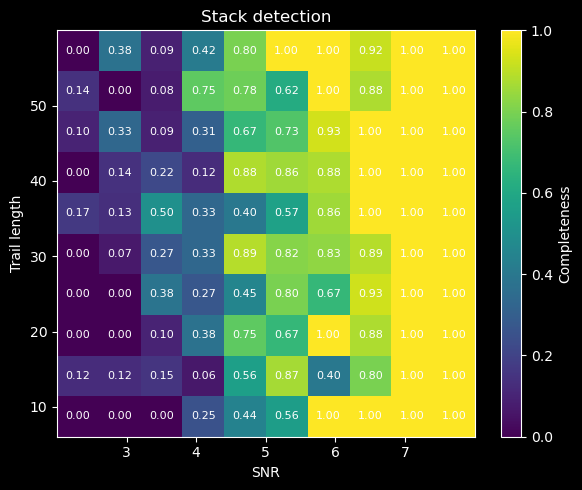

In [5]:
evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")
_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")
plt.show()

## Model

In [6]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_last.pt
Predictions shape: (50, 4004, 4096)


### Best threshold

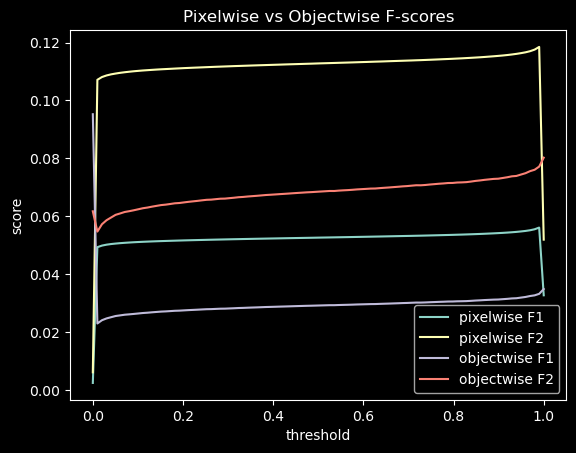

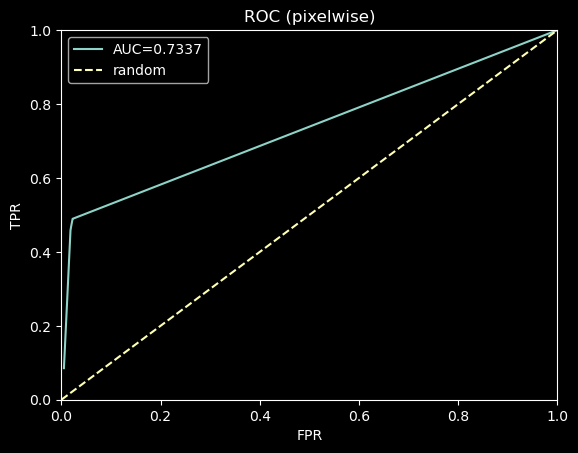

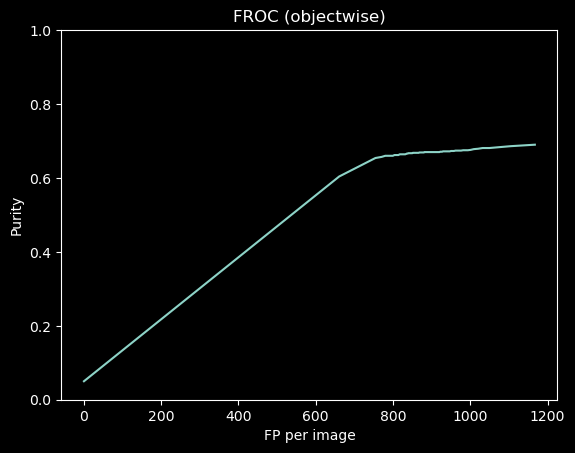

Object-level Confusion Matrix
F1 Score: 0.0355, F2 Score: 0.0815
                 Predicted Negative  Predicted Positive
Actual Negative                   0               32468
Actual Positive                 396                 604

Pixel-level Confusion Matrix
F1 Score: 0.0327, F2 Score: 0.0519
                 Predicted Negative  Predicted Positive
Actual Negative           814840419             4170173
Actual Positive              922489               86119

Combined Object-level Confusion Matrix
F1 Score: 0.0092, F2 Score: 0.0227
                 Predicted Negative  Predicted Positive
Actual Negative                   0              159678
Actual Positive                 254                 746



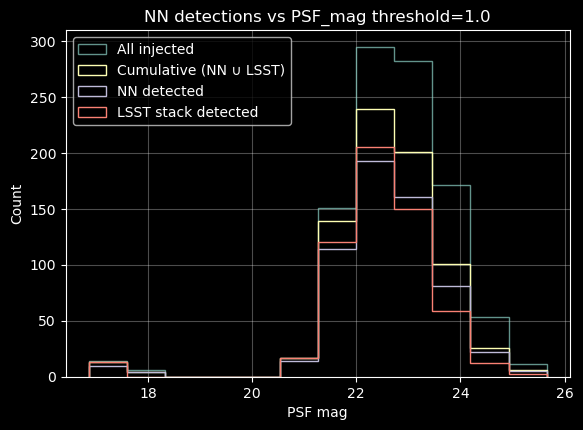

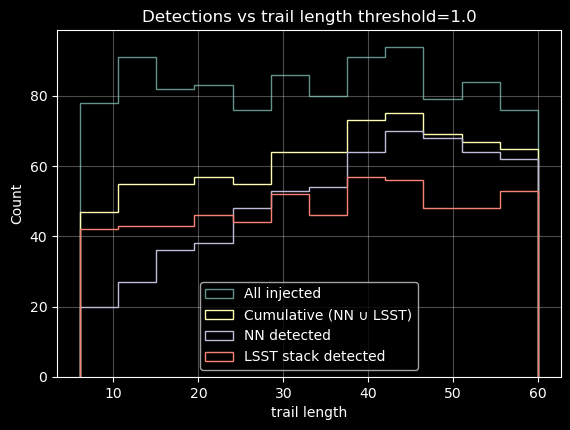

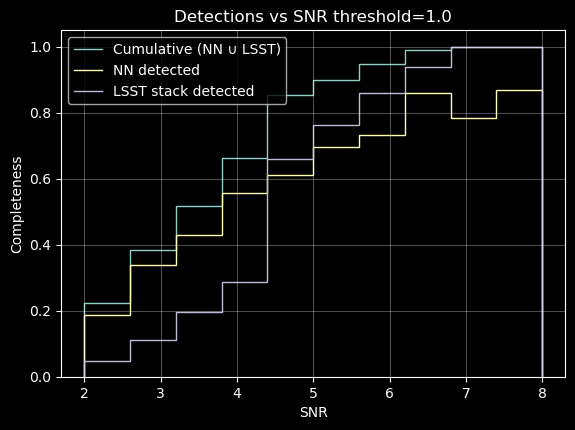

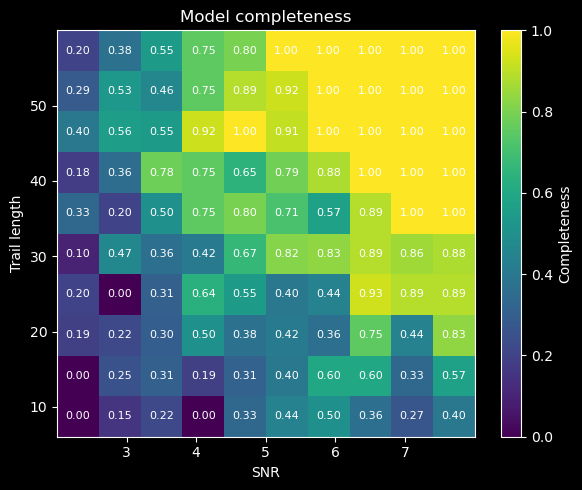

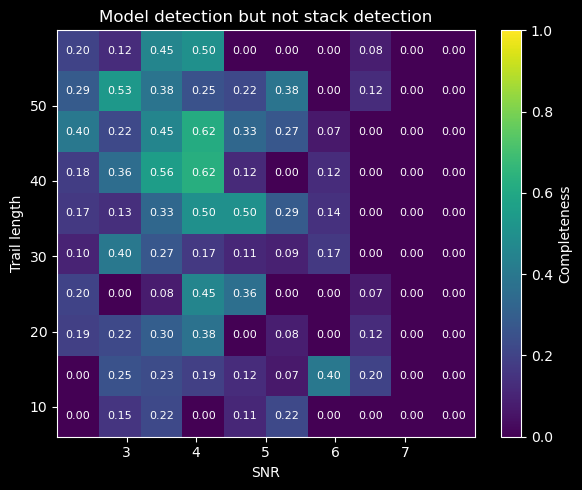

In [7]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

### 0.5 Threshold

Object-level Confusion Matrix
F1 Score: 0.0292, F2 Score: 0.0685
                 Predicted Negative  Predicted Positive
Actual Negative                   0               44215
Actual Positive                 330                 670

Pixel-level Confusion Matrix
F1 Score: 0.0526, F2 Score: 0.1128
                 Predicted Negative  Predicted Positive
Actual Negative           802329996            16680596
Actual Positive              530547              478061

Combined Object-level Confusion Matrix
F1 Score: 0.0091, F2 Score: 0.0224
                 Predicted Negative  Predicted Positive
Actual Negative                   0              171425
Actual Positive                 210                 790



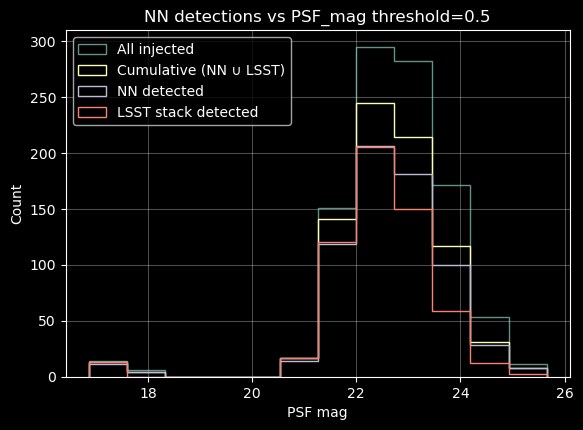

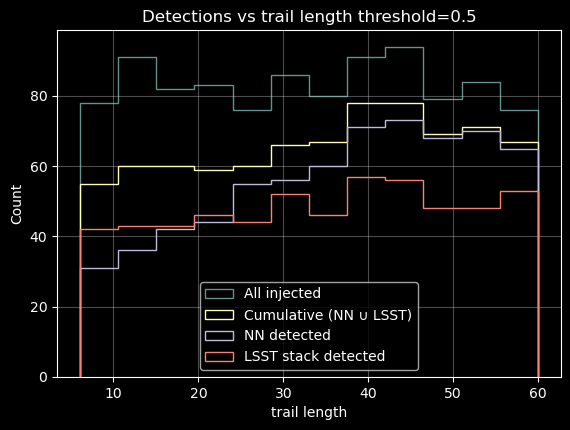

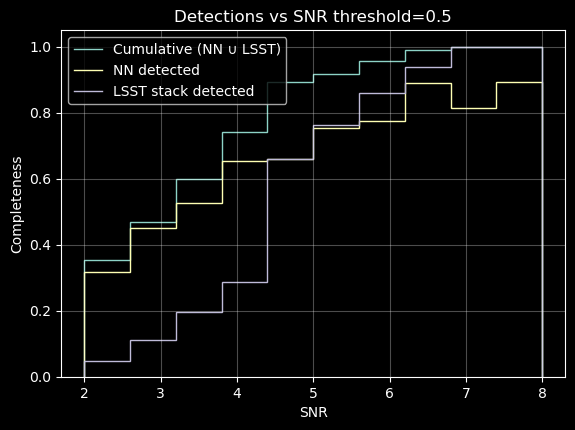

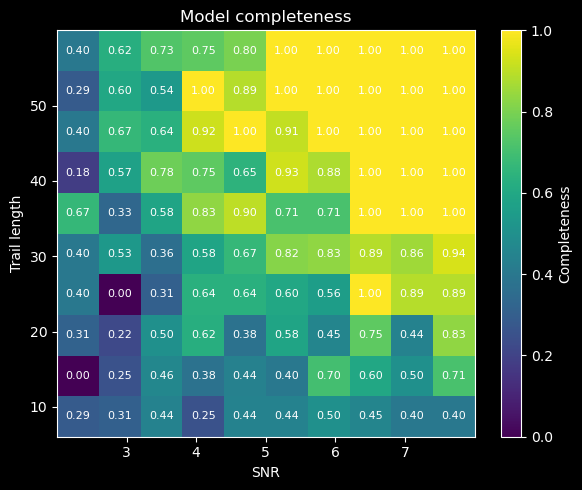

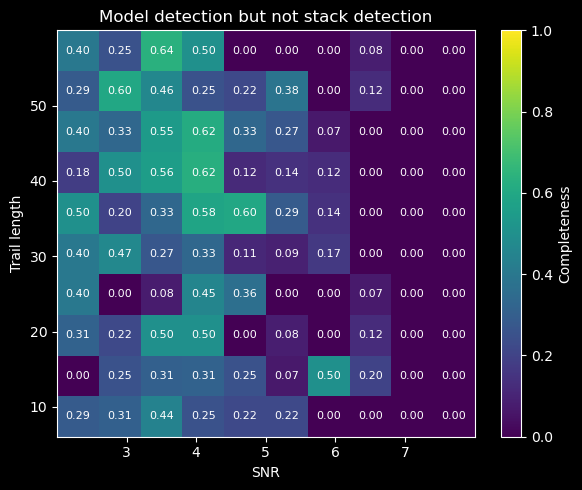

In [8]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

### Two stage classifier

Object-level Confusion Matrix
F1 Score: 0.0356, F2 Score: 0.0824
                 Predicted Negative  Predicted Positive
Actual Negative                   0               35817
Actual Positive                 333                 667

Pixel-level Confusion Matrix
F1 Score: 0.0508, F2 Score: 0.1097
                 Predicted Negative  Predicted Positive
Actual Negative           801311253            17699339
Actual Positive              521219              487389

Combined Object-level Confusion Matrix
F1 Score: 0.0091, F2 Score: 0.0224
                 Predicted Negative  Predicted Positive
Actual Negative                   0              171425
Actual Positive                 210                 790



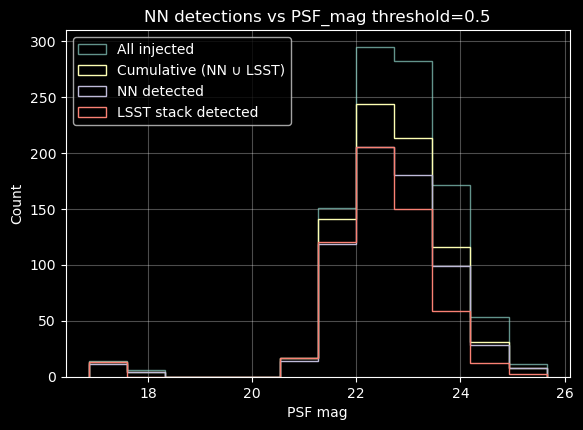

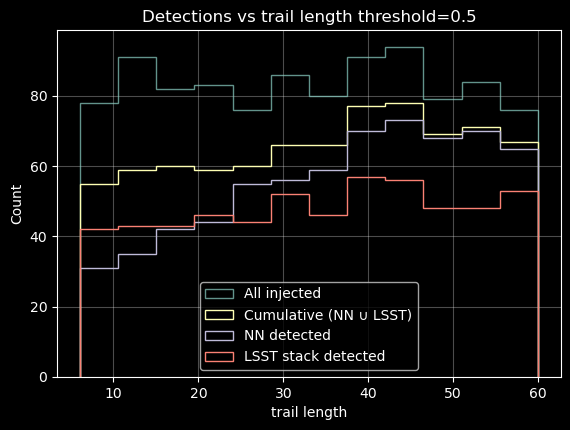

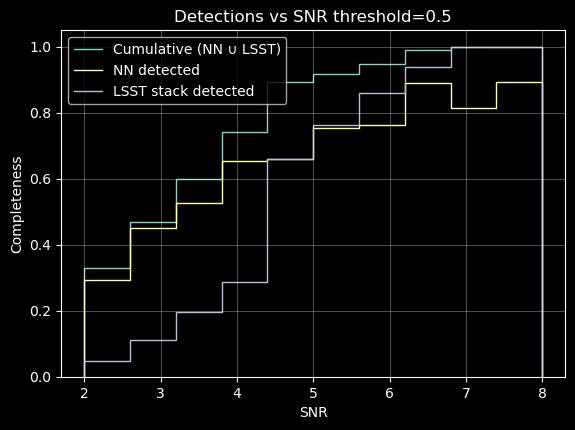

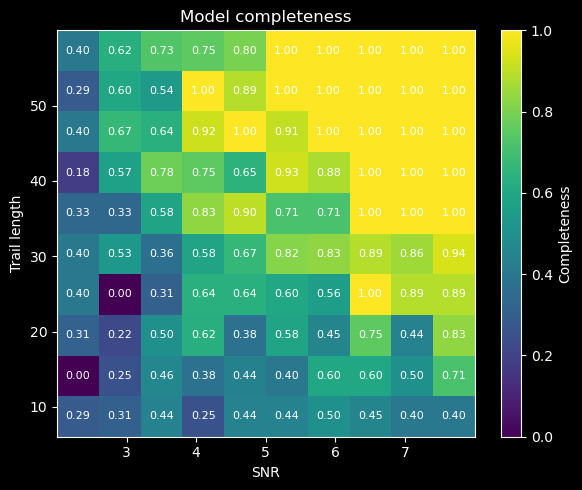

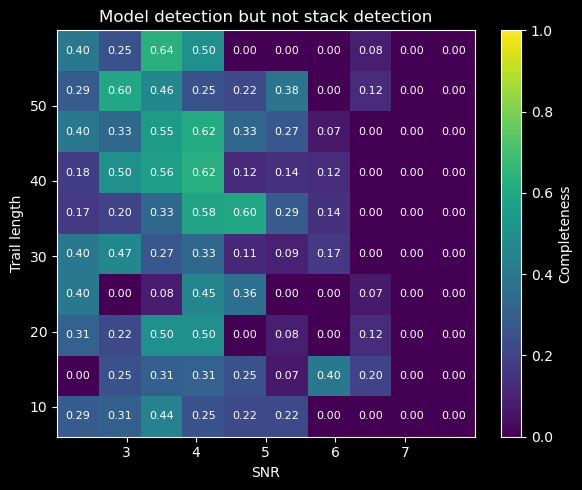

In [9]:
detections, keep_masks = second_stage_detect_batch_mp(
    p,
    t_low=0.05,
    score_thr=0.5,
    score_mode="max",
    min_area=1,
    min_span=5,
    min_aspect=1,
    return_mask=True,
    max_workers=32,
    chunk_size=64,
)

__ = calculate_model_metrics(test_catalog, keep_masks, gt_test, stack_fp=stack_fp, best_threshold=0.5)

# 4 sigma threshold

In [10]:
test_h5 = "./DATA/test_SNR4.h5"
test_csv = "./DATA/test_SNR4.csv"

ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

Object-wise Confusion Matrix
F1 Score: 0.0093, F2 Score: 0.0227
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              162593
Actual Positive                 239                 761



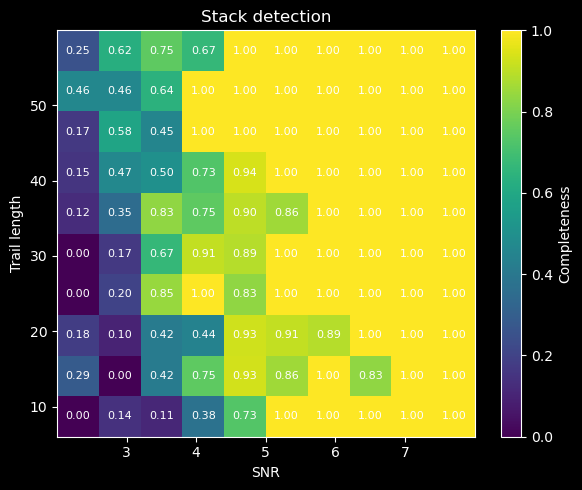

In [11]:
evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")
_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")
plt.show()

## Model

In [12]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_last.pt
Predictions shape: (50, 4004, 4096)


### Best threshold

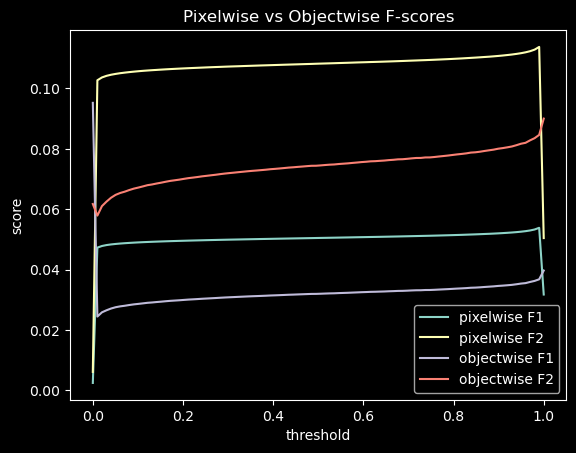

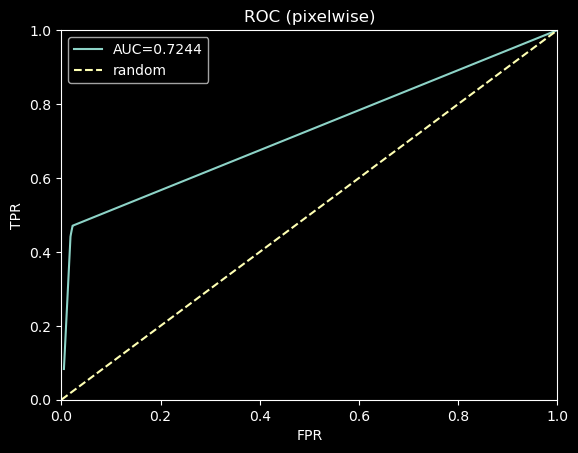

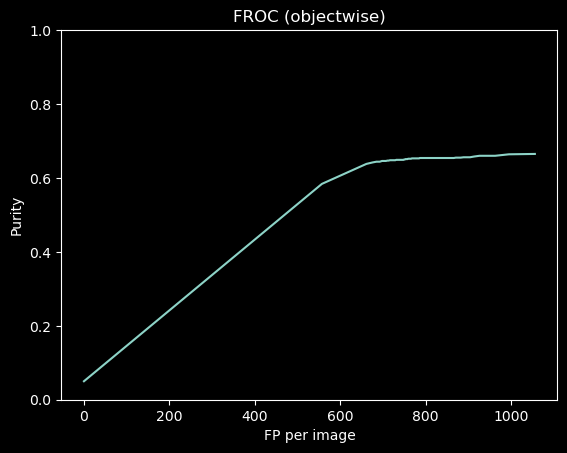

Object-level Confusion Matrix
F1 Score: 0.0404, F2 Score: 0.0915
                 Predicted Negative  Predicted Positive
Actual Negative                   0               27335
Actual Positive                 416                 584

Pixel-level Confusion Matrix
F1 Score: 0.0317, F2 Score: 0.0504
                 Predicted Negative  Predicted Positive
Actual Negative           814847839             4168135
Actual Positive              919859               83367

Combined Object-level Confusion Matrix
F1 Score: 0.0085, F2 Score: 0.0209
                 Predicted Negative  Predicted Positive
Actual Negative                   0              189928
Actual Positive                 185                 815



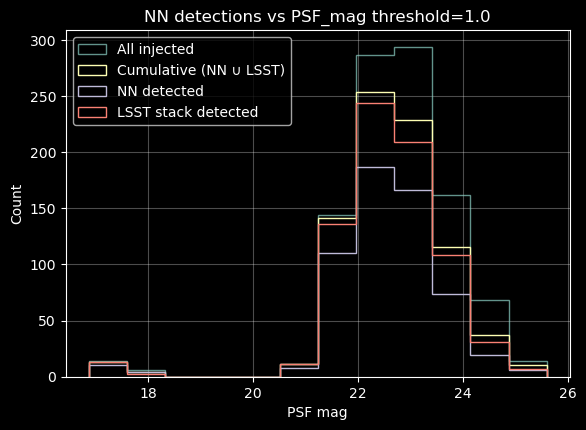

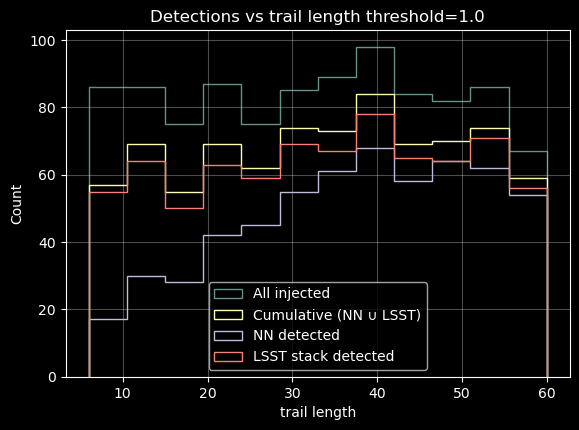

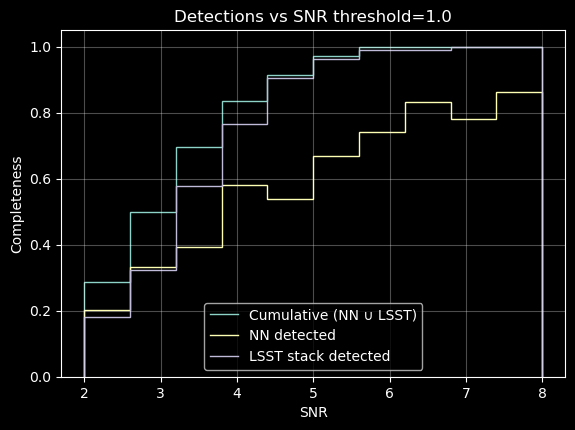

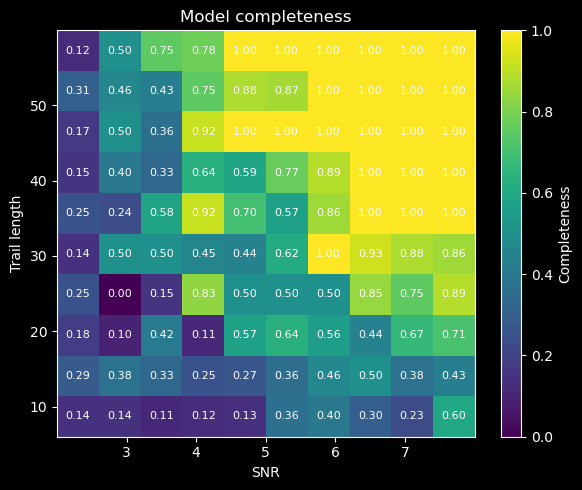

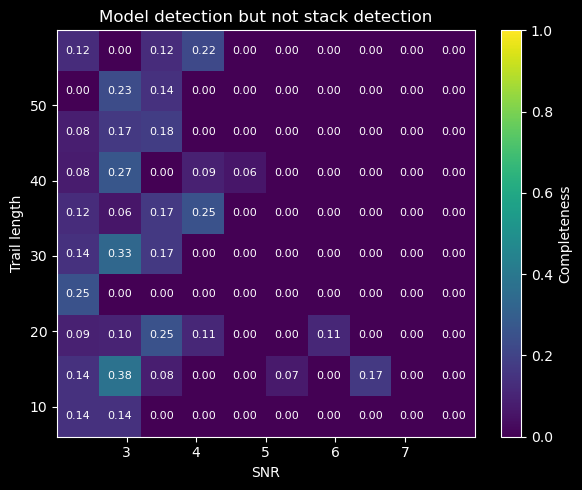

In [13]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

### 0.5 threshold

Object-level Confusion Matrix
F1 Score: 0.0320, F2 Score: 0.0745
                 Predicted Negative  Predicted Positive
Actual Negative                   0               39177
Actual Positive                 347                 653

Pixel-level Confusion Matrix
F1 Score: 0.0505, F2 Score: 0.1082
                 Predicted Negative  Predicted Positive
Actual Negative           802342699            16673275
Actual Positive              545591              457635

Combined Object-level Confusion Matrix
F1 Score: 0.0083, F2 Score: 0.0204
                 Predicted Negative  Predicted Positive
Actual Negative                   0              201770
Actual Positive                 158                 842



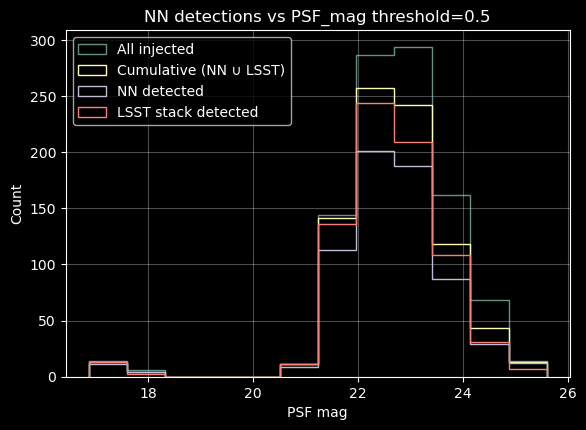

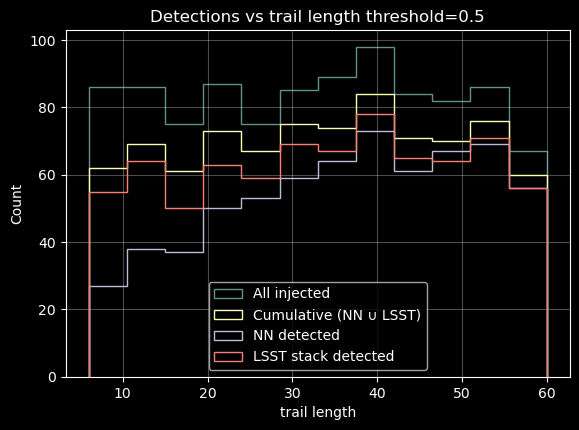

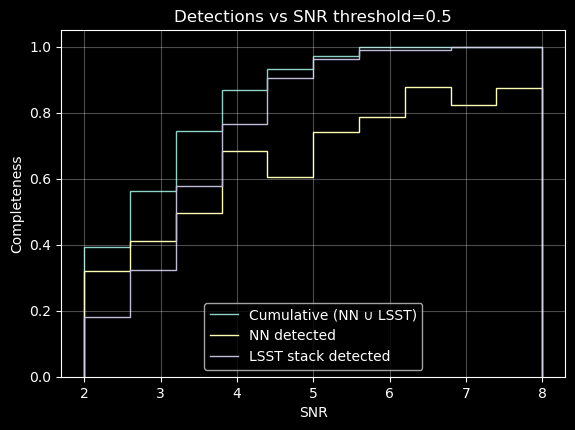

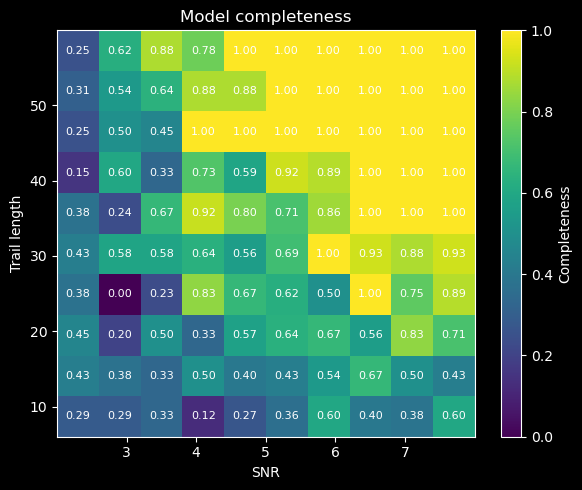

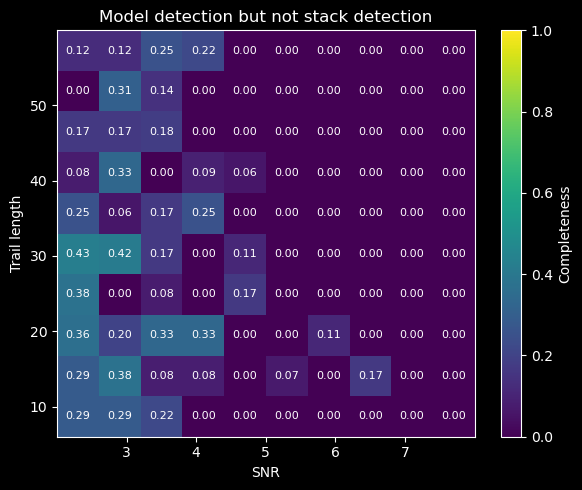

In [14]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

### Two stage classifier

Object-level Confusion Matrix
F1 Score: 0.0399, F2 Score: 0.0914
                 Predicted Negative  Predicted Positive
Actual Negative                   0               31014
Actual Positive                 348                 652

Pixel-level Confusion Matrix
F1 Score: 0.0487, F2 Score: 0.1052
                 Predicted Negative  Predicted Positive
Actual Negative           801322526            17693448
Actual Positive              536779              466447

Combined Object-level Confusion Matrix
F1 Score: 0.0083, F2 Score: 0.0204
                 Predicted Negative  Predicted Positive
Actual Negative                   0              201770
Actual Positive                 158                 842



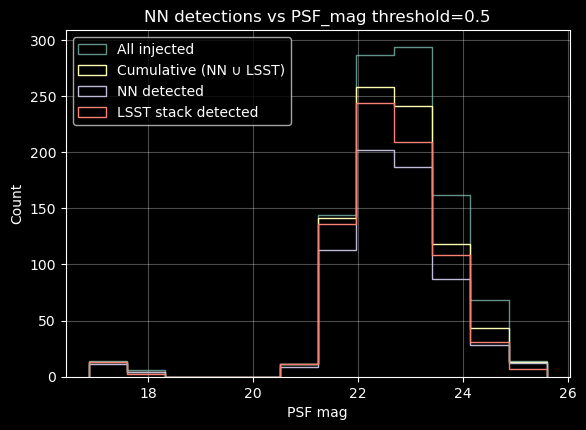

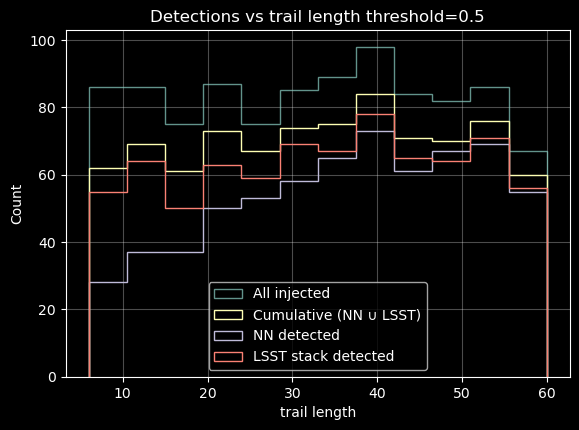

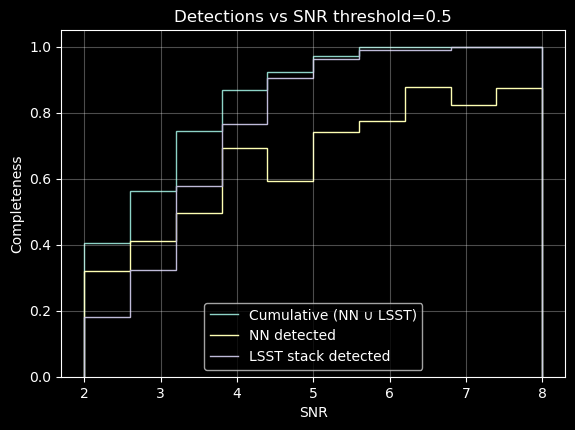

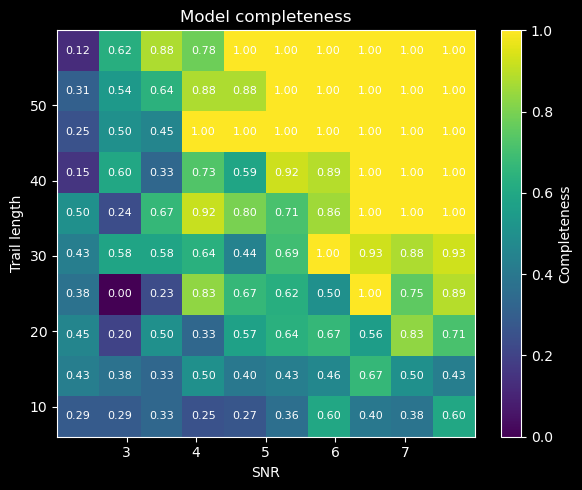

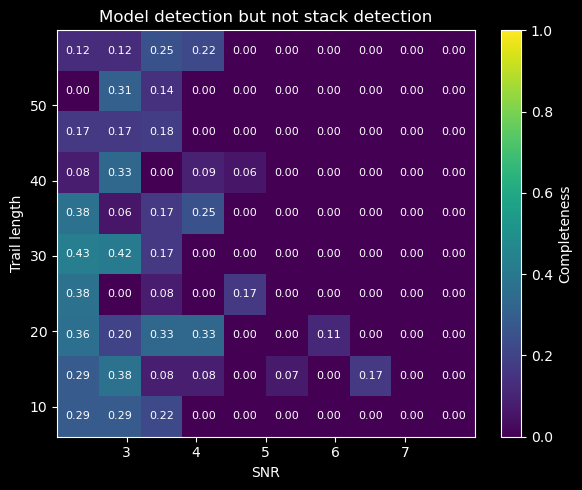

In [15]:
detections, keep_masks = second_stage_detect_batch_mp(
    p,
    t_low=0.05,
    score_thr=0.5,
    score_mode="max",
    min_area=1,
    min_span=5,
    min_aspect=1,
    return_mask=True,
    max_workers=32,
    chunk_size=64,
)

__ = calculate_model_metrics(test_catalog, keep_masks, gt_test, stack_fp=stack_fp, best_threshold=0.5)

# 3 sigma threshold

In [16]:
test_h5 = "./DATA/test_SNR3.h5"
test_csv = "./DATA/test_SNR3.csv"

ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

Object-wise Confusion Matrix
F1 Score: 0.0061, F2 Score: 0.0151
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              293413
Actual Positive                 102                 898



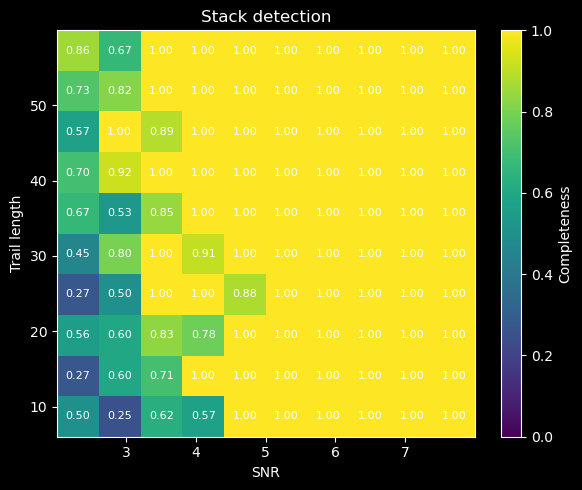

In [17]:
evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")
_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")

## Model

In [18]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_last.pt
Predictions shape: (50, 4004, 4096)


### Best threshold

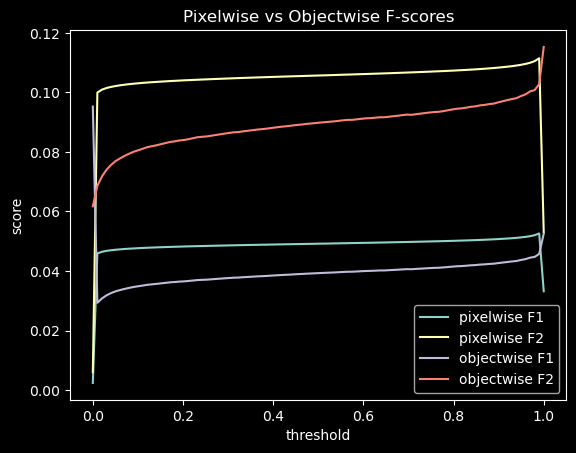

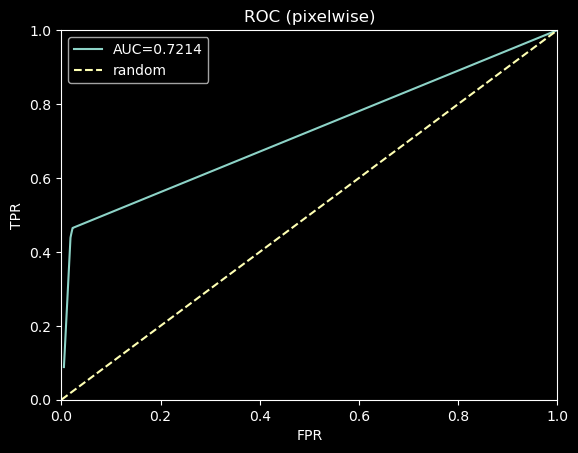

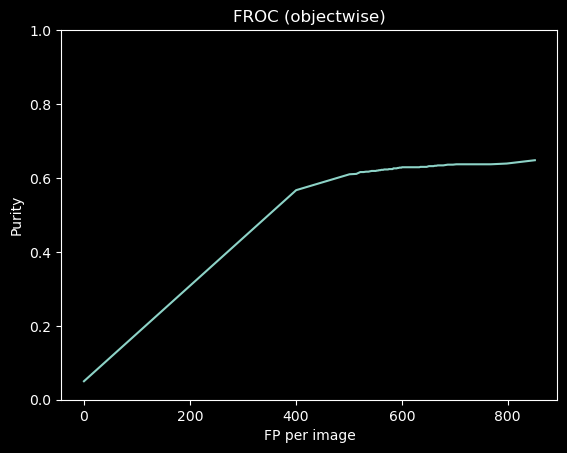

Object-level Confusion Matrix
F1 Score: 0.0537, F2 Score: 0.1176
                 Predicted Negative  Predicted Positive
Actual Negative                   0               19534
Actual Positive                 433                 567

Pixel-level Confusion Matrix
F1 Score: 0.0332, F2 Score: 0.0531
                 Predicted Negative  Predicted Positive
Actual Negative           814861589             4172395
Actual Positive              898182               87034

Combined Object-level Confusion Matrix
F1 Score: 0.0058, F2 Score: 0.0143
                 Predicted Negative  Predicted Positive
Actual Negative                   0              312947
Actual Positive                  93                 907



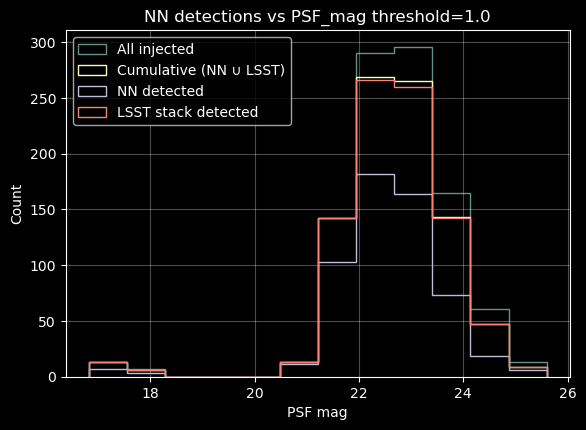

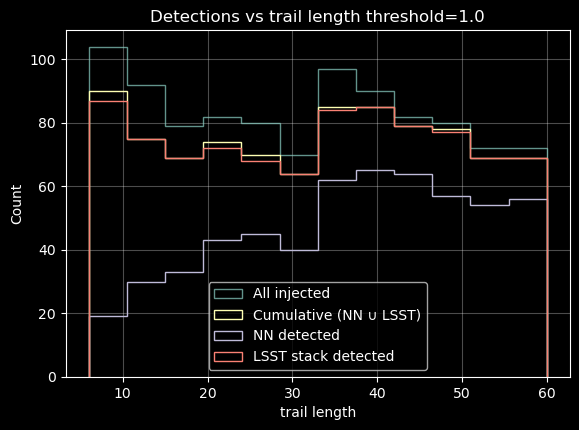

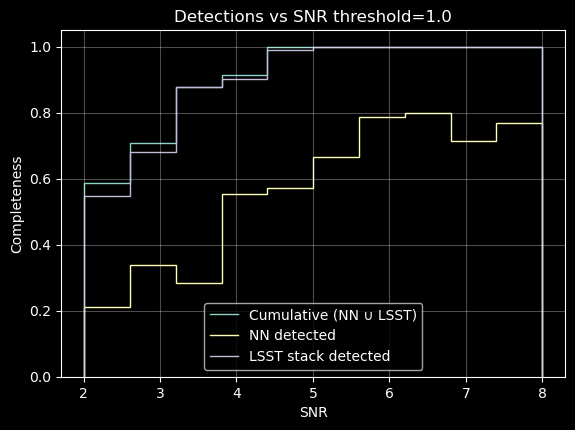

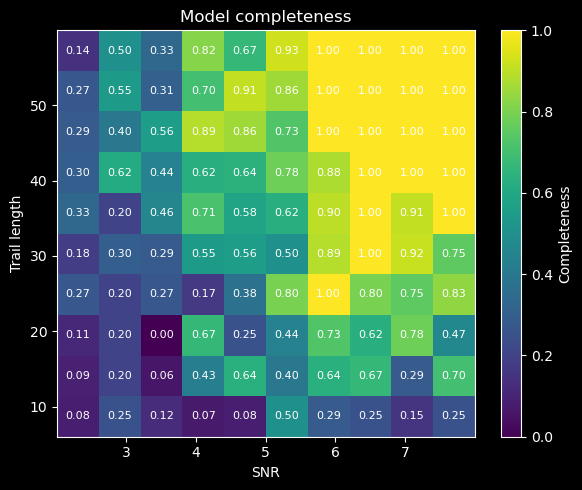

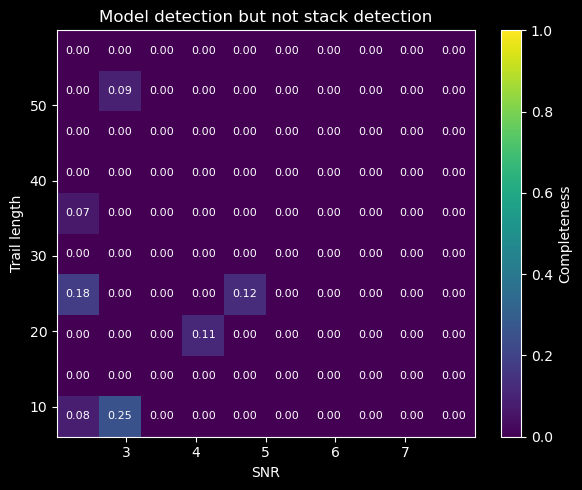

In [19]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

### 0.5 Threshold

Object-level Confusion Matrix
F1 Score: 0.0393, F2 Score: 0.0898
                 Predicted Negative  Predicted Positive
Actual Negative                   0               30374
Actual Positive                 371                 629

Pixel-level Confusion Matrix
F1 Score: 0.0492, F2 Score: 0.1057
                 Predicted Negative  Predicted Positive
Actual Negative           802362155            16671829
Actual Positive              540217              444999

Combined Object-level Confusion Matrix
F1 Score: 0.0056, F2 Score: 0.0139
                 Predicted Negative  Predicted Positive
Actual Negative                   0              323787
Actual Positive                  85                 915



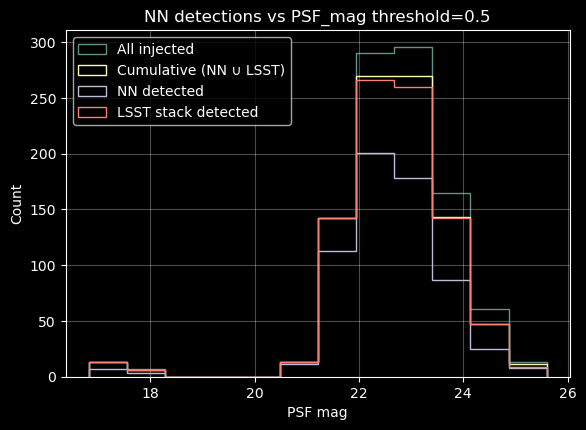

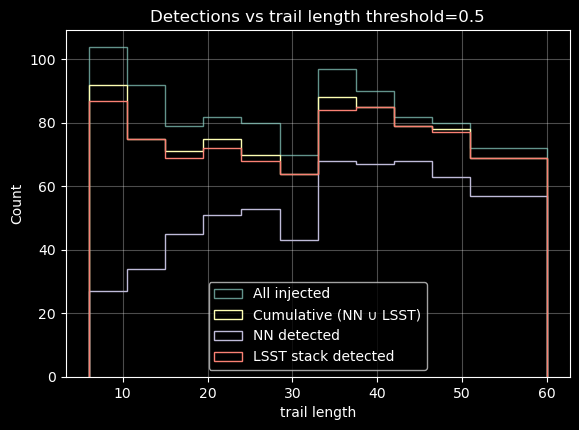

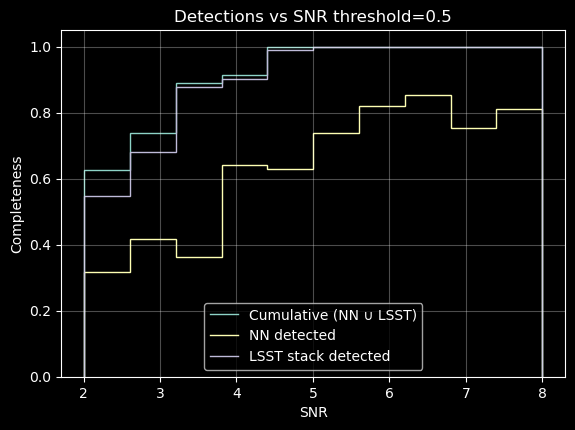

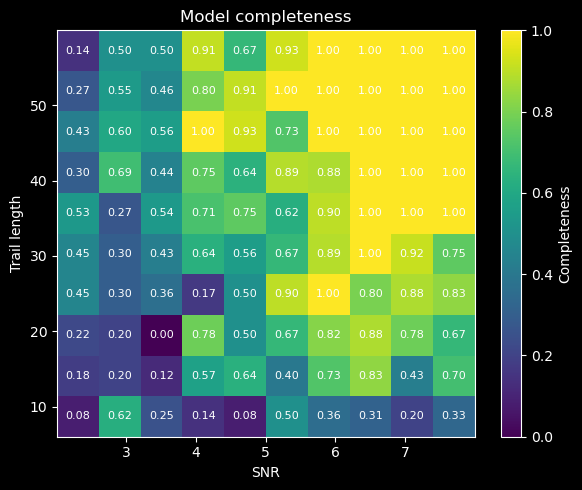

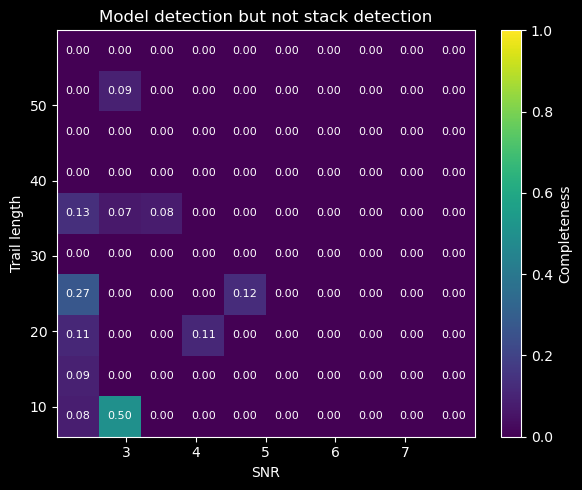

In [20]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

### Two stage classifier

Object-level Confusion Matrix
F1 Score: 0.0507, F2 Score: 0.1130
                 Predicted Negative  Predicted Positive
Actual Negative                   0               22864
Actual Positive                 379                 621

Pixel-level Confusion Matrix
F1 Score: 0.0473, F2 Score: 0.1025
                 Predicted Negative  Predicted Positive
Actual Negative           801343211            17690773
Actual Positive              532595              452621

Combined Object-level Confusion Matrix
F1 Score: 0.0056, F2 Score: 0.0139
                 Predicted Negative  Predicted Positive
Actual Negative                   0              323787
Actual Positive                  85                 915



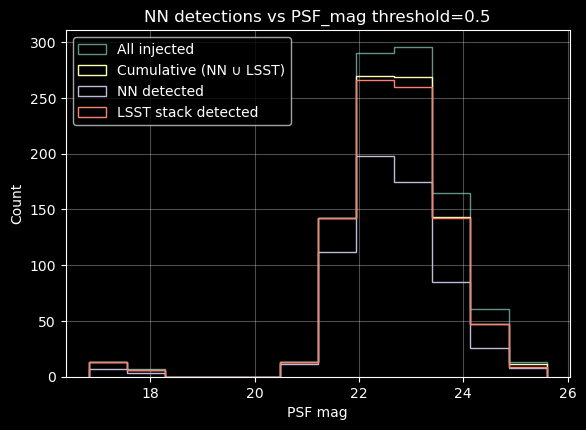

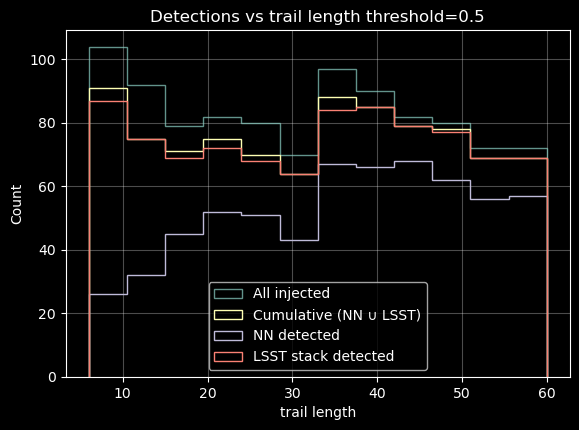

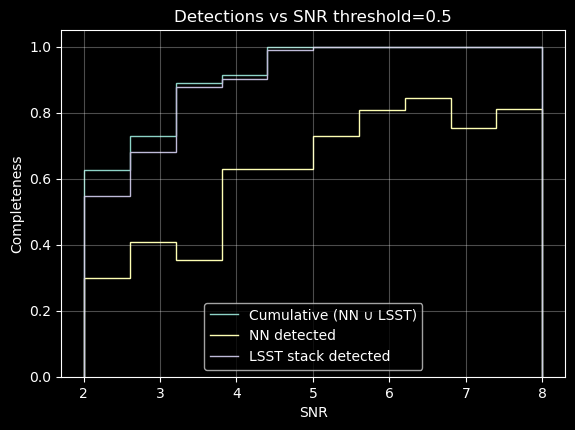

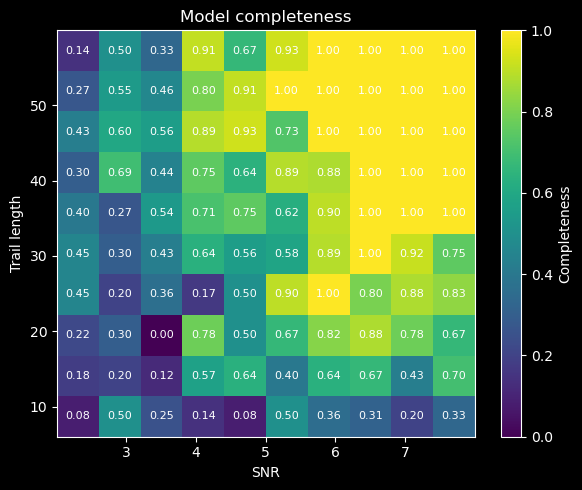

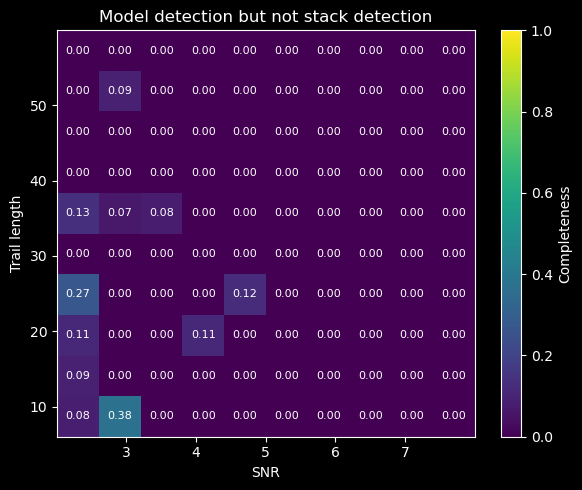

In [21]:
detections, keep_masks = second_stage_detect_batch_mp(
    p,
    t_low=0.05,
    score_thr=0.5,
    score_mode="max",
    min_area=1,
    min_span=5,
    min_aspect=1,
    return_mask=True,
    max_workers=32,
    chunk_size=64,
)

__ = calculate_model_metrics(test_catalog, keep_masks, gt_test, stack_fp=stack_fp, best_threshold=0.5)

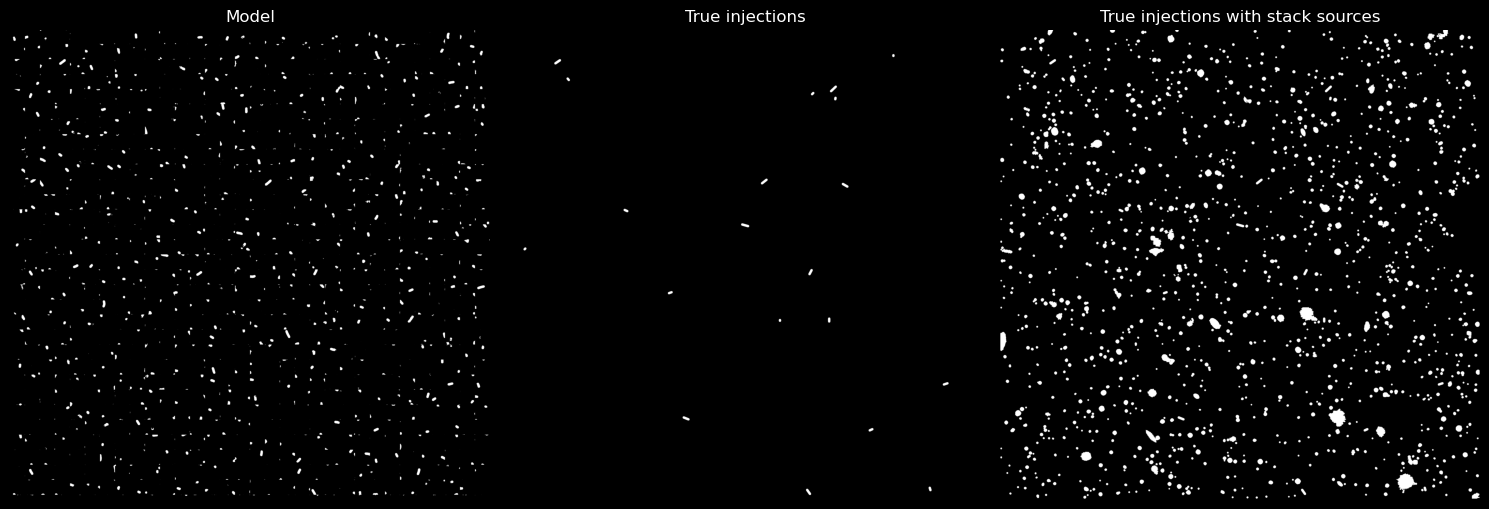

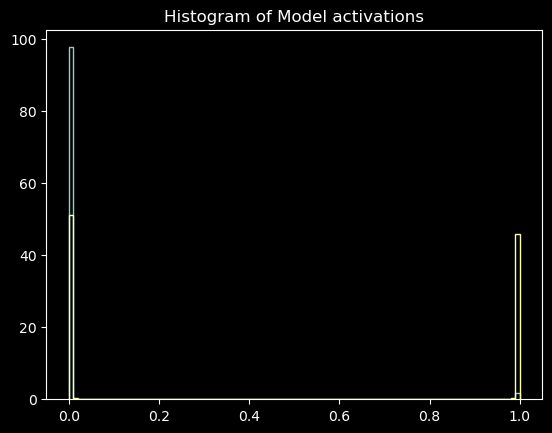

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(p[0], cmap='gray', vmin=0, vmax=1)
ax[0].axis('off')
ax[0].set_title("Model")
ax[1].imshow((gt_test[0]), cmap='gray', vmin=0, vmax=1)
ax[1].axis('off')
ax[1].set_title("True injections")
ax[2].imshow((gt_test[0] | (stack_fp[0] > 0.5)), cmap='gray', vmin=0, vmax=1)
ax[2].axis('off')
ax[2].set_title("True injections with stack sources")
fig.tight_layout()
plt.show()
plt.hist(p[gt_test<0.5].flatten(), density=True, bins=100, histtype='step')
plt.hist(p[gt_test>0.5].flatten(), density=True, bins=100, histtype='step')
plt.title("Histogram of Model activations")
plt.show()